In [1]:
%display latex

In [2]:
import numpy as np
from scipy.integrate import odeint

# Симуляція руху подвійного маятника

Олександра Перконос, Ларченко Максим

Маємо два фізичні маятники однакової маси та довжини у яких маса розподілена рівномірно по об'єму.
Один маятник кріпиться до кінця другого. Їх рух обмежений двовимірною площиною.

<img src="pendulum.png" width="300">

Введемо наступні позначення як показано на малюнку:
($x_1$, $y_1$), ($x_2$, $y_2$) - координати **центрів мас** першого та другого маятника відповідно
$\theta_1, \theta_2$ - кути відхиленння від вертикалі маятників
l, m, g - відповідно довжина, маса кожного з маятників та прискорення вільного падіння.
Початок координат декартової системи розташувається в точці кріплення верхнього маятника.

Знайдемо зв'язок між координатами ($x_1$, $y_1$), ($x_2$, $y_2$) та кутами $\theta_1, \theta_2$.
Маємо:
$$x_1 = \frac{1}{2} \ell \sin \theta_1$$
$$y_1 = -\frac{1}{2} \ell \cos \theta_1$$
$$x_2 = \ell \left( \sin \theta_1 + \frac{1}{2} \sin \theta_2 \right)$$
$$y_2 = -\ell \left( \cos \theta_1 + \frac{1}{2} \cos \theta_2 \right)$$

Виведемо рівняння руху, що повертатиме кути $\theta_1, \theta_2$, швидкості руху центрів мас та їх прискорення в заданий момент часу $t$. Для цього використаємо Лагранжіан
$$ \mathcal{L}  = W_k - W_p$$
де $W_k$, $W_p$ - кінетична та потенціальна енергії механічної системи.
Лагранжіан дозволяє визначити стан системи в довільний момент часу через взаємозв'язок кінетичної енергії (швидкість) та потенціальної енергії (висота).

Кінетична енергія тіла є сумою кінетичної енергії його поступального руху $\frac{mv^2}{2}$ та обертального $\frac{I \omega^2}{2}$, де $I$ - момент інерції, а $\omega$ - кутова швидкість. В нашому випадку момент інерції обчислюється як $$I = \frac{m \ell^2}{12}$$ Потенціальна енергія - це $mgh$, отже маємо для нашого випадку
$$
\mathcal{L} = \frac{1}{2} m \left( v_1^2 + v_2^2 \right) + \frac{1}{2} I \left( \omega_1^2 + \omega_2^2 \right) - mg(y_1 + y_2)
$$
Позначатимо похідну функції по часу через точку згори. Матимемо
$$\omega_i = \dot{\theta_i}$$
Також за теоремою Піфагора знайдемо швидкості
$$v^2 = v_x^2 + v_y^2$$
де
$$v_x = \dot{x}, v_y = \dot{y}$$

Нижче знайдемо Лагранжіан за допомогою SageMath. Оголосимо змінні та функції для того, щоб брати похідні і банально спростимо вираз методом .full_simplify()

In [3]:
t = var('t')

theta1 = function('theta1')(t)
theta2 = function('theta2')(t)

m, l, g = var('m l g')

dtheta1 = theta1.derivative(t)
dtheta2 = theta2.derivative(t)

x1 = (1/2)*l*sin(theta1)
y1 = -(1/2)*l*cos(theta1)

x2 = l*(sin(theta1) + (1/2)*sin(theta2))
y2 = -l*(cos(theta1) + (1/2)*cos(theta2))

v1_sq = x1.derivative(t)^2 + y1.derivative(t)^2
v2_sq = x2.derivative(t)^2 + y2.derivative(t)^2

W_k = (1/2)*m*(v1_sq + v2_sq) + (1/2)*((m*l^2)/12)*(dtheta1^2 + dtheta2^2)
W_p = m*g*y1 + m*g*y2

L = W_k - W_p

Lagr = L.full_simplify()
show("Отримали Лагранжіан:")
print("L =")
show(Lagr)

'Отримали Лагранжіан:'

L =


2/3*l^2*m*diff(theta1(t), t)^2 + 1/6*l^2*m*diff(theta2(t), t)^2 + 3/2*g*l*m*cos(theta1(t)) + 1/2*g*l*m*cos(theta2(t)) + 1/2*(l^2*m*cos(theta1(t))*cos(theta2(t))*diff(theta1(t), t) + l^2*m*sin(theta1(t))*sin(theta2(t))*diff(theta1(t), t))*diff(theta2(t), t)

Далі використаємо фізичну модель - рівняння Ойлера-Лагранжа, яке дозволяє отримати рівняння руху тіл, тобто залежність кутів, кутових швидкостей та прискорень. Рівняння Ойлера-Лагранжа має вигляд:

$$\frac{d}{dt} \frac{\partial \mathcal{L}}{\partial \dot{\theta}_i} - \frac{\partial \mathcal{L}}{\partial \theta_i} = 0, \quad i = 1, 2.$$

Оскільки theta1, theta2, dtheta1, dtheta2 - це функції від часу, то для того, щоб взяти похідну введемо відповідні заміни q1, q2, v1, v2 за допомогою методу .subs(). Після того, як похідна взята, переназвемо змінні назад, щоб все було добре. Далі підставляємо вирази у формулу рівняння для кожного з тіл та спрощуємо вирази.

In [4]:
q1, q2, v1, v2 = var('q1 q2 v1 v2')
dLddtheta1 = L.subs({dtheta1: v1}).diff(v1).subs({v1: dtheta1})
dLddtheta2 = L.subs({dtheta2: v2}).diff(v2).subs({v2: dtheta2})

eq1_raw = dLddtheta1.derivative(t) - L.subs({theta1: q1}).diff(q1).subs({q1: theta1}) == 0
eq2_raw = dLddtheta2.derivative(t) - L.subs({theta2: q2}).diff(q2).subs({q2: theta2}) == 0
eq1 = eq1_raw.full_simplify()
eq2 = eq2_raw.full_simplify()
show("Перше рівняння руху")
show(eq1)
show("Друге рівняння руху")
show(eq2)

'Перше рівняння руху'

3/2*g*l*m*sin(theta1(t)) + 4/3*l^2*m*diff(theta1(t), t, t) + 1/2*(l^2*m*cos(theta2(t))*sin(theta1(t)) - l^2*m*cos(theta1(t))*sin(theta2(t)))*diff(theta2(t), t)^2 + 1/2*(l^2*m*cos(theta1(t))*cos(theta2(t)) + l^2*m*sin(theta1(t))*sin(theta2(t)))*diff(theta2(t), t, t) == 0

'Друге рівняння руху'

1/3*l^2*m*diff(theta2(t), t, t) - 1/2*(l^2*m*sin(theta1(t))*diff(theta1(t), t)^2 - l^2*m*cos(theta1(t))*diff(theta1(t), t, t))*cos(theta2(t)) + 1/2*(l^2*m*cos(theta1(t))*diff(theta1(t), t)^2 + l^2*m*sin(theta1(t))*diff(theta1(t), t, t) + g*l*m)*sin(theta2(t)) == 0

Тепер треба виразити $\ddot{\theta}_1, \ddot{\theta}_2,$ через всі інші змінні, щоб в подальшому підставити це у функцію, яка вирішуватиме систему чотирьох диференціальних рівнянь першого порядку. Знову введемо заміни, щоб SageMath не лаявся на те, що він не розуміє змінних. Бо, бачите, він дуже лякається, коли його просять виразити другу похідну по часу через інші змінні. Йому треба просто позначити це якимось значком і тоді він все зробить.

In [5]:
var1, var2 = var('var1 var2')
eq1_new = eq1.subs({theta1.diff(t, 2): var1}, {theta2.diff(t, 2): var2})
eq2_new = eq2.subs({theta1.diff(t, 2): var1}, {theta2.diff(t, 2): var2})

Функція solve() вирішує рівняння відносно відповідних змінних.

In [6]:
solutions = solve([eq1_new, eq2_new], var1, var2)

Маємо колекцію розв'язків у вигляді var1 == ... var2 == ...  
Але нам треба саме вирази, отже використаю метод .rhs()

In [7]:
print("Кутове прискорення першого маятника:")
print(solutions[0][0].rhs())

Кутове прискорення першого маятника:
3*(3*l*cos(theta1(t))*cos(theta2(t))^2*sin(theta1(t))*diff(theta1(t), t)^2 - 3*(l*cos(theta1(t))*diff(theta1(t), t)^2 + g)*sin(theta1(t))*sin(theta2(t))^2 - 3*(l*cos(theta1(t))^2*diff(theta1(t), t)^2 - l*sin(theta1(t))^2*diff(theta1(t), t)^2 + g*cos(theta1(t)))*cos(theta2(t))*sin(theta2(t)) + 2*(l*cos(theta2(t))*sin(theta1(t)) - l*cos(theta1(t))*sin(theta2(t)))*diff(theta2(t), t)^2 + 6*g*sin(theta1(t)))/(9*l*cos(theta1(t))^2*cos(theta2(t))^2 + 18*l*cos(theta1(t))*cos(theta2(t))*sin(theta1(t))*sin(theta2(t)) + 9*l*sin(theta1(t))^2*sin(theta2(t))^2 - 16*l)


In [8]:
print("Кутове прискорення другого маятника:")
print(solutions[0][1].rhs())

Кутове прискорення другого маятника:
-3*((8*l*diff(theta1(t), t)^2 + 9*g*cos(theta1(t)))*cos(theta2(t))*sin(theta1(t)) + 3*(l*cos(theta1(t))*cos(theta2(t))^2*sin(theta1(t)) - l*cos(theta1(t))*sin(theta1(t))*sin(theta2(t))^2 - (l*cos(theta1(t))^2 - l*sin(theta1(t))^2)*cos(theta2(t))*sin(theta2(t)))*diff(theta2(t), t)^2 - (8*l*cos(theta1(t))*diff(theta1(t), t)^2 - 9*g*sin(theta1(t))^2 + 8*g)*sin(theta2(t)))/(9*l*cos(theta1(t))^2*cos(theta2(t))^2 + 18*l*cos(theta1(t))*cos(theta2(t))*sin(theta1(t))*sin(theta2(t)) + 9*l*sin(theta1(t))^2*sin(theta2(t))^2 - 16*l)


Отримали проблемку. Функція solve() виводить нам вирази із змінними у вигляді функцій від часу і похідних, а для того, щоб вирішувач odeint() вирішив диф. рівняння, він має чітко бачити змінні, як звичайні змінні, а не функції. Тим паче ми задаємо кути і кутові швидкості як початкові дані. Тому для цього банально переведемо ці вирази у зрозумілі для вирішувача.

In [9]:
def format_for_python(expr):
    s = str(expr)

    s = s.replace('diff(theta1(t), t)', 'dtheta1')
    s = s.replace('diff(theta2(t), t)', 'dtheta2')

    s = s.replace('theta1(t)', 'theta1')
    s = s.replace('theta2(t)', 'theta2')

    s = s.replace('^', '**')
    s = s.replace('sin', 'np.sin')
    s = s.replace('cos', 'np.cos')
    return s

print("Перше рівняння")
print(format_for_python(solutions[0][0].rhs()))
print("Друге рівняння")
print(format_for_python(solutions[0][1].rhs()))

Перше рівняння
3*(3*l*np.cos(theta1)*np.cos(theta2)**2*np.sin(theta1)*dtheta1**2 - 3*(l*np.cos(theta1)*dtheta1**2 + g)*np.sin(theta1)*np.sin(theta2)**2 - 3*(l*np.cos(theta1)**2*dtheta1**2 - l*np.sin(theta1)**2*dtheta1**2 + g*np.cos(theta1))*np.cos(theta2)*np.sin(theta2) + 2*(l*np.cos(theta2)*np.sin(theta1) - l*np.cos(theta1)*np.sin(theta2))*dtheta2**2 + 6*g*np.sin(theta1))/(9*l*np.cos(theta1)**2*np.cos(theta2)**2 + 18*l*np.cos(theta1)*np.cos(theta2)*np.sin(theta1)*np.sin(theta2) + 9*l*np.sin(theta1)**2*np.sin(theta2)**2 - 16*l)
Друге рівняння
-3*((8*l*dtheta1**2 + 9*g*np.cos(theta1))*np.cos(theta2)*np.sin(theta1) + 3*(l*np.cos(theta1)*np.cos(theta2)**2*np.sin(theta1) - l*np.cos(theta1)*np.sin(theta1)*np.sin(theta2)**2 - (l*np.cos(theta1)**2 - l*np.sin(theta1)**2)*np.cos(theta2)*np.sin(theta2))*dtheta2**2 - (8*l*np.cos(theta1)*dtheta1**2 - 9*g*np.sin(theta1)**2 + 8*g)*np.sin(theta2))/(9*l*np.cos(theta1)**2*np.cos(theta2)**2 + 18*l*np.cos(theta1)*np.cos(theta2)*np.sin(theta1)*np.sin(thet

Оскільки функція format_for_python() повертає текстовий рядок у лапках, то нам доведеться надрукувати ці вирази через print і вручну скопійювати у відповідні змінні для функції double_pendulum(), яка бере наші рівняння, підставляє у них задані початкові значення кутів та кутових швидкостей та повертає колекцію виразів, яку буде виріщувати функція odeint()

Задамо прискорення вільного падіння, масу та довжину маятників як константи

In [10]:
g = 9.81
m = 1.0
l = 1.0

def double_pendulum(thetas, t):
    theta1, dtheta1, theta2, dtheta2 = thetas[0], thetas[1], thetas[2], thetas[3]
    ddtheta1 = (3*(3*l*np.cos(theta1)*np.cos(theta2)**2*np.sin(theta1)*dtheta1**2 
                   - 3*(l*np.cos(theta1)*dtheta1**2 + g)*np.sin(theta1)*np.sin(theta2)**2 
                   - 3*(l*np.cos(theta1)**2*dtheta1**2 - l*np.sin(theta1)**2*dtheta1**2 
                   + g*np.cos(theta1))*np.cos(theta2)*np.sin(theta2) + 2*(l*np.cos(theta2)*np.sin(theta1) 
                   - l*np.cos(theta1)*np.sin(theta2))*dtheta2**2 + 6*g*np.sin(theta1))/(9*l*np.cos(theta1)**2*np.cos(theta2)**2 
                   + 18*l*np.cos(theta1)*np.cos(theta2)*np.sin(theta1)*np.sin(theta2) + 9*l*np.sin(theta1)**2*np.sin(theta2)**2 - 16*l))
    ddtheta2 = (-3*((8*l*dtheta1**2 + 9*g*np.cos(theta1))*np.cos(theta2)*np.sin(theta1) 
                   + 3*(l*np.cos(theta1)*np.cos(theta2)**2*np.sin(theta1) 
                   - l*np.cos(theta1)*np.sin(theta1)*np.sin(theta2)**2 - (l*np.cos(theta1)**2 
                   - l*np.sin(theta1)**2)*np.cos(theta2)*np.sin(theta2))*dtheta2**2 - (8*l*np.cos(theta1)*dtheta1**2 
                   - 9*g*np.sin(theta1)**2 + 8*g)*np.sin(theta2))/(9*l*np.cos(theta1)**2*np.cos(theta2)**2 
                   + 18*l*np.cos(theta1)*np.cos(theta2)*np.sin(theta1)*np.sin(theta2) + 9*l*np.sin(theta1)**2*np.sin(theta2)**2 - 16*l))

    return [dtheta1, ddtheta1, dtheta2, ddtheta2]

**колекція `start_cond` задає кути і швидкості, від зміни їх змінюється графік**  
**Також задамо часовий проміжок `time_period` за допомогою функції із numpy**

In [45]:
time_period = np.linspace(0, 25, 2500)

In [46]:
start_cond_1 = [float(pi/2), 0.0, float(pi/2), 0.0]

solution1 = odeint(double_pendulum, start_cond_1, time_period)

theta11 = solution1[:, 0]
theta21 = solution1[:, 2]

x11 = l * np.sin(theta11)
y11 = -l * np.cos(theta11)

x21 = x11 + l * np.sin(theta21)
y21 = y11 - l * np.cos(theta21)

На графіках зображено траекторію руху нижнього кінця другого маятника

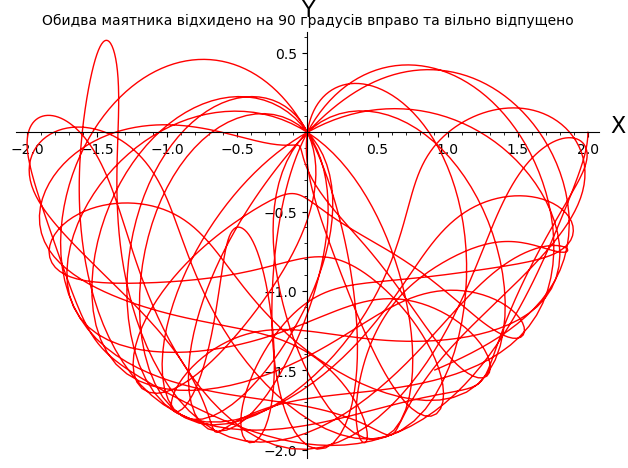

In [47]:
p1 = list_plot(list(zip(x21, y21)), plotjoined=True, color='red', axes_labels=['X', 'Y'], title="Обидва маятника відхидено на 90 градусів вправо та вільно відпущено")
show(p1)

In [48]:
start_cond_2 = [float(-pi/2), -6.0, float(pi/6), 10.0]

solution2 = odeint(double_pendulum, start_cond_2, time_period)

theta12 = solution2[:, 0]
theta22 = solution2[:, 2]

x12 = l * np.sin(theta12)
y12 = -l * np.cos(theta12)

x22 = x12 + l * np.sin(theta22)
y22 = y12 - l * np.cos(theta22)

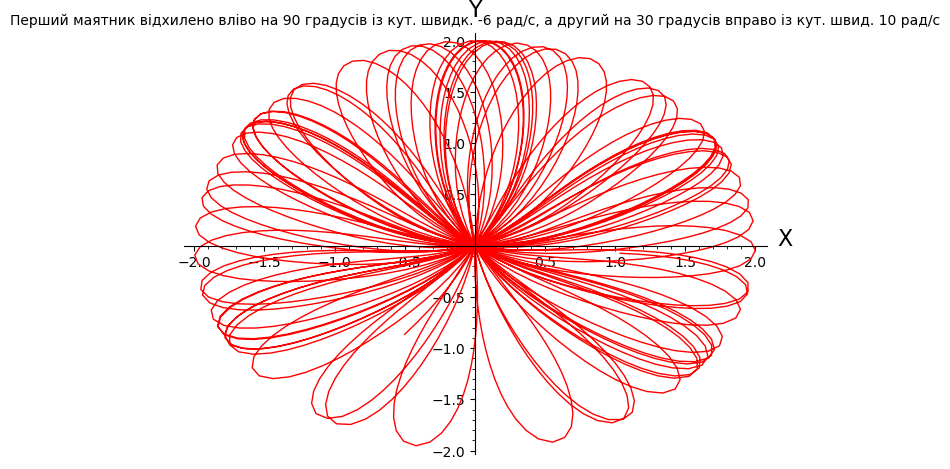

In [49]:
p2 = list_plot(list(zip(x22, y22)), plotjoined=True, color='red', axes_labels=['X', 'Y'], title="Перший маятник відхилено вліво на 90 градусів із кут. швидк. -6 рад/с, а другий на 30 градусів вправо із кут. швид. 10 рад/с")
show(p2)

In [50]:
start_cond_3 = [float(-pi/4), -10.0, float(pi/2), 10.0]

solution3 = odeint(double_pendulum, start_cond_3, time_period)

theta13 = solution3[:, 0]
theta23 = solution3[:, 2]

x13 = l * np.sin(theta13)
y13 = -l * np.cos(theta13)

x23 = x13 + l * np.sin(theta23)
y23 = y13 - l * np.cos(theta23)

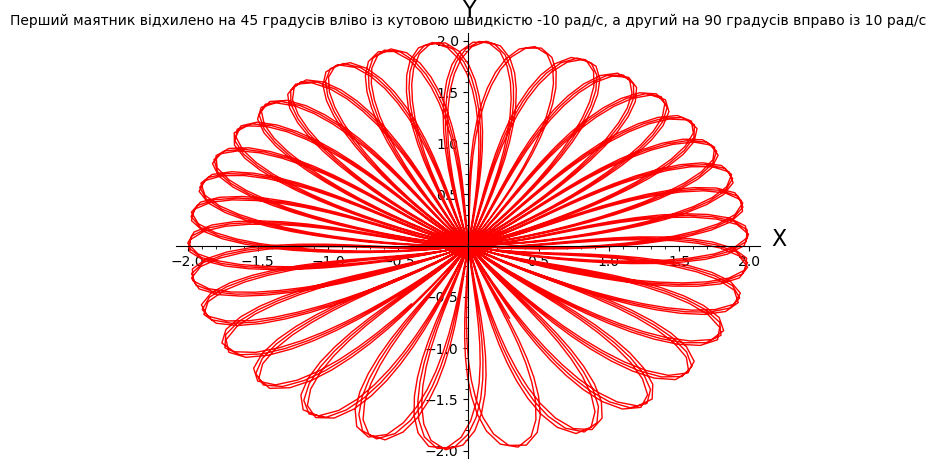

In [51]:
p3 = list_plot(list(zip(x23, y23)), plotjoined=True, color='red', axes_labels=['X', 'Y'], title = "Перший маятник відхилено на 45 градусів вліво із кутовою швидкістю -10 рад/с, а другий на 90 градусів вправо із 10 рад/с")
show(p3)

**Звідки береться графік**
ми будуємо його чисельним методом, тобото:
1. Функція `odeint` розбиває заданий проміжок часу (25 секунд) на 2500 крихітних кроків.
2. На кожному мікрокроці алгоритм підставляє поточні кути та швидкості в рівняння Лагранжа, знаходить миттєве прискорення і робить крок у майбутнє.
3. Результатом роботи `odeint` є не формула, а **масив із 2500 числових значень** кутів $\theta_1$ та $\theta_2$ для кожного моменту часу.
4. За допомогою тригонометричних формул ми переводимо ці кути у Декартові координати ($X_2, Y_2$) для нижнього тягарця.

Графік, який ми бачимо — це просто 2500 точок, що послідовно з'єднані між собою прямими лініями.